# Test 4: Event Localization using Bisection Search

In [1]:
import sys
from typing import Any, Dict, Optional, List
from pathlib import Path

import numpy as np

from SysSimX.core.base import CoSimComponent
from SysSimX.core.port import PortSpec, PortType
from SysSimX.core.events import Event
from SysSimX.system.system import System
from SysSimX.system.connection import EventConnection
from SysSimX.utilities.units import Quantity
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

-------------------------------------------

## Modelica Reference Solution

--------------------------------------

## Implementation with Hybrid Algorithm

In [2]:
class Pendulum(FMUComponent):
    """
    FMU-based pendulum component with rollback support.
    """
    def __init__(self, name, group = "Pendulum", solver: str = "Cvode"):
        # Select FMU based on solver choice
        if solver == "Euler":
            fmu_path = Path.cwd().parent / "FMUs" / "Pendulum_Euler.fmu"
        elif solver == "Cvode":
            fmu_path = Path.cwd().parent / "FMUs" / "Pendulum_Cvode.fmu"
        self.solver = solver
        
        # Initialize base class
        super().__init__(name, fmu_path, group)

        # Add event input port for omega inversion
        self.input_specs.update({
            'omega_invert': PortSpec('omega_invert', PortType.EVENT, "in")
        })


    def snapshot_state(self):
        if self.solver == "Euler":
            # returns pointer to internal FMU state
            return self._instance.getFMUState()
        elif self.solver == "Cvode":
            # returns dict with outputs
            return super().get_state()
    
    def restore_state(self, snapshot, t):
        self.t = t
        if self.solver == "Euler":
            self._instance.setFMUState(snapshot)
        elif self.solver == "Cvode":
            # 1) Extract State variable        
            q0 = snapshot['q']['value']
            omega0 = snapshot['omega']['value']

            # 2) Full Re-Initialization Sequence
            self._instance.reset()
            self._instance.instantiate()
            self._instance.setupExperiment(startTime=t)
            self._instance.enterInitializationMode()

            # 3) Set initial conditions as parameters
            self.set_parameters(**{'q0': q0, 'omega0': omega0})
            self._apply_parameters_starts()
            self._apply_input_starts()

            # 4) Exit Initialization Mode
            self._instance.exitInitializationMode()
        
        self._update_output_states(t)
        self._record_outputs(t)

    # Handle events: invert omega on wall hit
    def _handle_events_internal(self, event_names, t):
        if "wall_hit" not in event_names:
            return
        # 1) Get current current state
        output = self.get_state()
        q0 = output['q']['value']
        omega0 = -output['omega']['value']

        # 2) Full Re-Initialization Sequence
        self._instance.reset()
        self._instance.instantiate()
        self._instance.setupExperiment(startTime=t)
        self._instance.enterInitializationMode()

        # 3) Set initial conditions as parameters
        self.set_parameters(**{'q0': q0, 'omega0': omega0})
        self._apply_parameters_starts()
        self._apply_input_starts()

        # 4) Exit Initialization Mode
        self._instance.exitInitializationMode()

        self._update_output_states(t, event_names)
        self._record_outputs(t)
    
    def _update_output_states(self, t: Optional[float]=None, event_names: Optional[List[str]]=[]):
        super()._update_output_states(t)
        if event_names:
            for event_name in event_names:
                if event_name in self.output_specs.keys():
                    self.outputs[event_name].set(value=True, t=t)
        else:
            for out_port in self.outputs.values():
                if out_port.spec.type == PortType.EVENT:
                    out_port.set(value=False, t=t)
        


In [3]:
# 1) Create pendulum component
pendulum = Pendulum(name="pendulum")
pendulum.set_parameters(q0=0.3)

# 2) Define event indicator function
def event_indicator_function(comp: Pendulum) -> float:
    """Event indicator: pendulum angle (triggers when q=0)"""
    return comp.get_outputs()['q'].magnitude

# 3) Initialize component and add event indicator
pendulum.initialize(t0=0.0)

event = Event(name="wall_hit", source=pendulum.name, direction=-1)
pendulum.add_event_indicator(
    event.name,
    event_indicator_function,
    direction=event.direction
)
pendulum.subscribe_event(event=event)

# 4) Create system with single component
system = System(name="Single Pendulum Test")
system.add_component(pendulum)

# 5) Add event connections (event source to event input)
event_connection = EventConnection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs['wall_hit'].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs['omega_invert'].name
)
system.add_event_connection(event_connection)

# 6) Initialize system (will auto-select HybridAlgorithm)
system.initialize(t0=0.0)

print(f"Algorithm selected: {system.algorithm.name}")
print(f"Event sources: {[c.name for c in system.event_sources]}")
print(f"Event listeners: {[c.name for c in system.event_listeners]}")
print(f"Event targets: {system._event_targets_by_source}")

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [4]:
for name, model_variable in pendulum.parameters.items():
    print(f"{name}: {model_variable.start}")

L: 0.6055028481722639
g: 9.81
inertia: 18.90035177381065
m: 41.70369562497543
omega0: 0.0
q0: 0.3


In [5]:
# 6) Run simulation with event detection
t_start = 0.0
t_end = 1.0
dt = 0.01  # Macro step size

system.run(t0=t_start, tf=t_end, dt=dt)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

In [6]:
# 7) Extract and plot results
history = system.get_history()
pendulum_history = history['pendulum']
event_history = history['Events']

t_vals, data = pendulum_history
q_vals = data['q']
omega_vals = data['omega']

# Get event times
event_times = event_history.get(('pendulum', 'wall_hit'), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event:
    print(f"First event at t = {t_event.t:.8f} s")


Detected 1 events
First event at t = 0.43634319 s


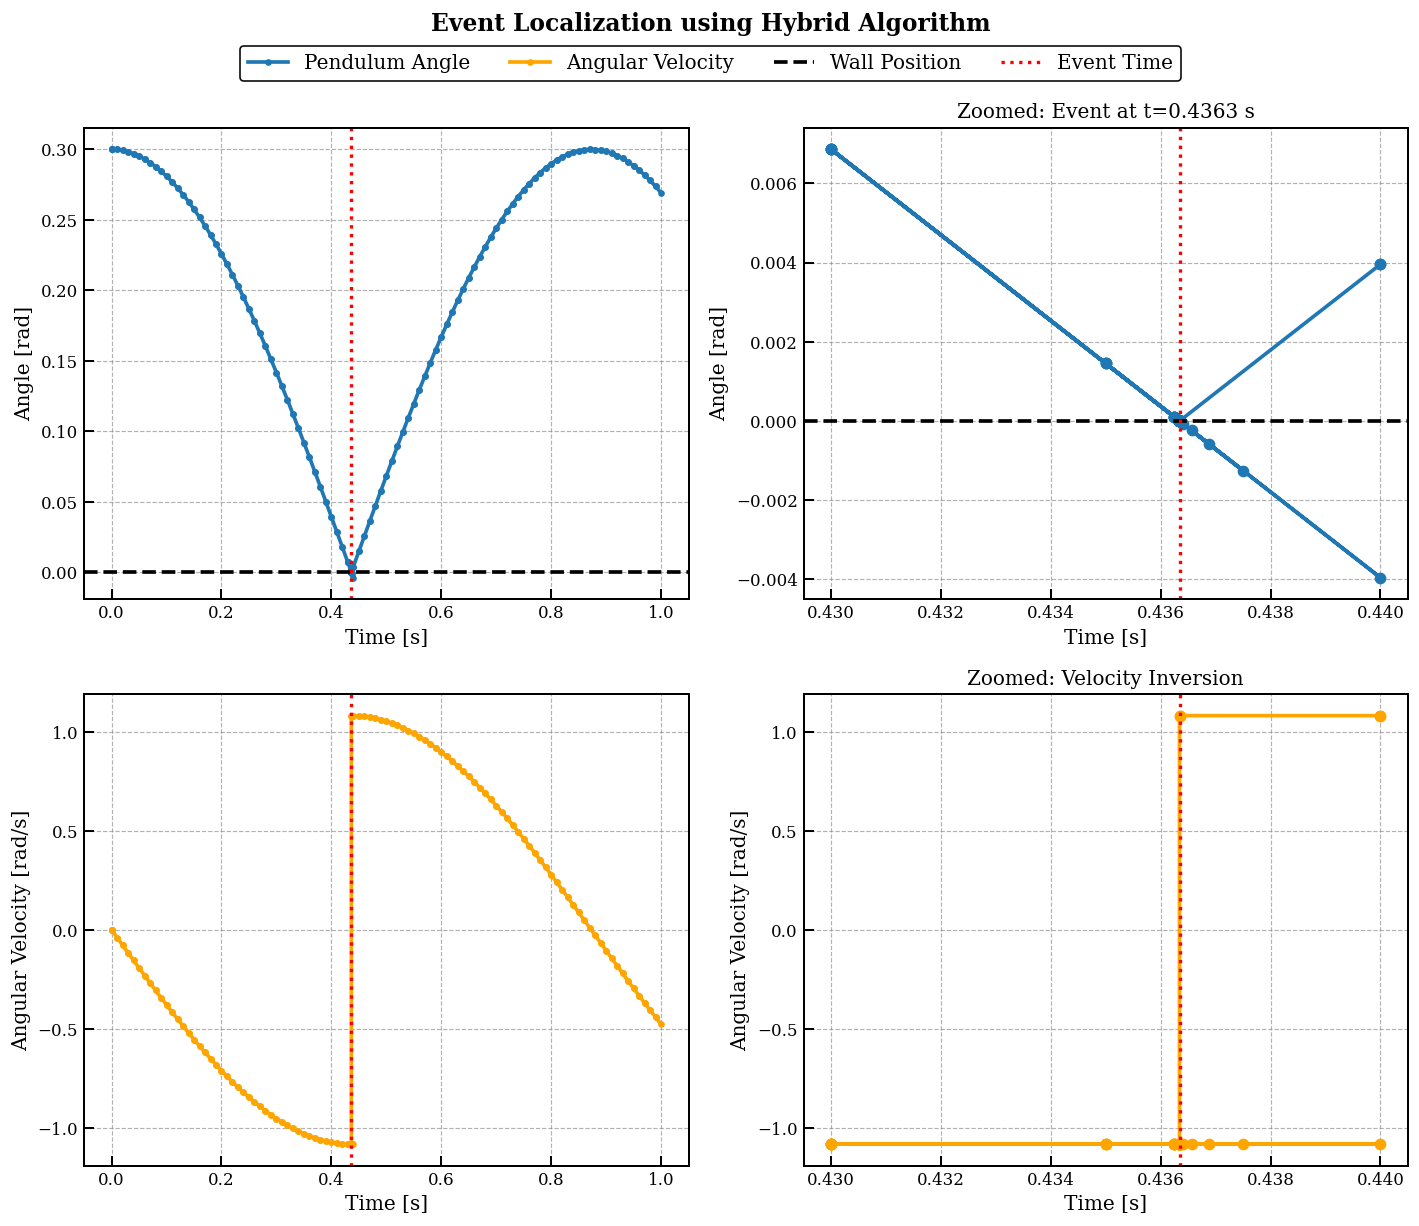

In [8]:
# 8) Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Event Localization using Hybrid Algorithm', 
             fontweight='bold', fontsize=14, y=1.02)

# Top left: Full angle trajectory
line1, = axs[0, 0].plot(t_vals, q_vals, label='Pendulum Angle', marker='o', markersize=3)
line2  = axs[0, 0].axhline(0, color='k', linestyle='--', label='Wall Position')
if t_event:
    line3 = axs[0, 0].axvline(t_event.t, color='red', linestyle=':', linewidth=2, 
                      label=f'Event Time')
axs[0, 0].set_xlabel('Time [s]')
axs[0, 0].set_ylabel('Angle [rad]')
axs[0, 0].grid()

# Top right: Zoomed angle near event
if t_event:
    zoom_window = 0.01
    mask = (t_vals >= t_event.t - zoom_window) & (t_vals <= t_event.t + zoom_window)
    axs[0, 1].plot(t_vals[mask], q_vals[mask], 'o-', markersize=6)
    axs[0, 1].axhline(0, color='k', linestyle='--')
    axs[0, 1].axvline(t_event.t, color='red', linestyle=':', linewidth=2)
    axs[0, 1].set_xlabel('Time [s]')
    axs[0, 1].set_ylabel('Angle [rad]')
    axs[0, 1].set_title(f'Zoomed: Event at t={t_event.t:.4f} s')
    axs[0, 1].grid()

# Bottom left: Full angular velocity
line4, = axs[1, 0].plot(t_vals, omega_vals, color='orange', label='Angular Velocity', marker='o', markersize=3)
if t_event:
    axs[1, 0].axvline(t_event.t, color='red', linestyle=':', linewidth=2)
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].set_ylabel('Angular Velocity [rad/s]')
axs[1, 0].grid()

# Bottom right: Zoomed velocity near event
if t_event:
    axs[1, 1].plot(t_vals[mask], omega_vals[mask], 'o-', color='orange', markersize=6)
    axs[1, 1].axvline(t_event.t, color='red', linestyle=':', linewidth=2)
    axs[1, 1].set_xlabel('Time [s]')
    axs[1, 1].set_ylabel('Angular Velocity [rad/s]')
    axs[1, 1].set_title('Zoomed: Velocity Inversion')
    axs[1, 1].grid()

signals = [line1, line4, line2, line3]
labels =  [s.get_label() for s in signals if s is not None]
fig.legend(signals, labels, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=4)

plt.tight_layout()
plt.savefig('../figures/Hybrid/test_2_location.svg')
plt.show()